<a href="https://colab.research.google.com/github/anthonyg2311/multivariate-regression-analysis/blob/main/(Newton's%20Method)%20Univariate_LinReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
#Due to runtime complexity of Newton's Method, I will only be using a univariate regression model.
data = pd.read_csv('california_housing_test.csv')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


In [13]:
X = data['median_income']
Y = data['median_house_value']

#Normalizing data
X = (X - X.min()) / (X.max() - X.min())
Y = (Y - Y.min()) / (Y.max() - Y.min())

X = np.array(X)
Y = np.array(Y)

In [14]:
def error(theta1, theta0):
  error =0
  for i in range(len(data)):
    error+= (1/len(data)) * ((theta1 * X[i]+theta0) - Y[i]) **2

  return error

Weights:  1.2460246030383866 0.09976288050887282
Cost:  0.030715123666684947


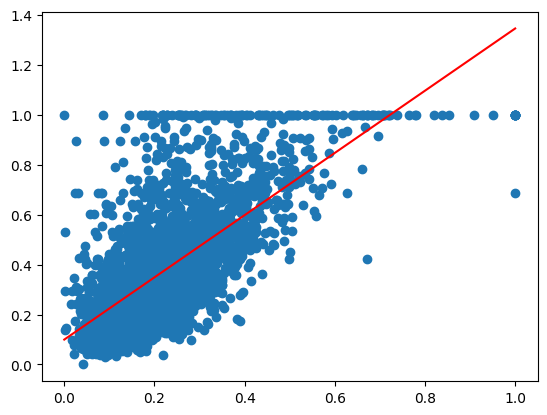

In [15]:
def newtonMethod(theta1, theta0, numExamples):
  #Initilaization
  dt1 = 0
  dt0 = 0

  #1st partial derivative calculation of cost function
  for i in range(numExamples):
    dt1+= (2/numExamples) * ((theta1 * X[i]+theta0) - Y[i]) * X[i]
    dt0+= (2/numExamples) * ((theta1 * X[i]+theta0) - Y[i])

  # Manually setting the second partial derivatives in the hessian, as 2x2 matrix.
  #Note that dealing with higher dimensional cases, this method is not best, gradient descent is preferred.

  #This case only has theta1 and theta0 as parameters, so I will just manually type them in.
  h11 = 0
  h12 = 0 # Note h12 = h21, due to regression model being linear, therefore continous.
  h22 = 0

  #2nd partial derivative calculation of cost function (Hessian)
  #(degree goes down by one)

  for i in range(numExamples):
      h11 += (2/numExamples) * X[i]**2
      h12 += (2/numExamples) * X[i] # h21 = h12
      h22 += (2/numExamples) * 1

  det = (h11 * h22) - (h12 * h12) # determinant to find inverse of 2x2 matrix

  #Newton's Method calculation(One iteration)
  theta1 = theta1 - ((h22*dt1 - h12*dt0) / det)
  theta0 = theta0 - ((-h12*dt1 + h11*dt0) / det)
  return theta1, theta0


#Parameter Initialization
theta1 = 0
theta0 = 0
numExamples = len(data)
epochs =1

for i in range(epochs):
  theta1, theta0 = newtonMethod(theta1, theta0, numExamples)

#Output
print("Weights: ", theta1, theta0)
print("Cost: ",error(theta1, theta0))

plt.scatter(X, Y)
plt.plot(list(range(0,2)), [theta1 * x +  theta0 for x in range(0,2)], color = "red")
plt.show()

SkLearn Comparison

In [16]:
from sklearn.linear_model import LinearRegression
lR = LinearRegression()
lR.fit(X.reshape(-1,1),Y.reshape(-1,1))
print("Weights: ", (lR.coef_, lR.intercept_))
print("Cost: ",error(lR.coef_, lR.intercept_))

Weights:  (array([[1.2460246]]), array([0.09976288]))
Cost:  [[0.03071512]]
